### df_clean_Type2.csv 생성

In [34]:
import pandas as pd
import os

# 1. 원본 데이터 불러오기
input_path = "../../data/df_clean_nf.csv"
df = pd.read_csv(input_path)

# 2. Product_Type이 2인 데이터만 필터링
df_filtered = df[df['Product_Type'] == 2]

# 3. 새로운 파일 이름으로 저장하기
output_path = "../../data/df_clean_Type2.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_filtered.to_csv(output_path, index=False)

In [35]:
file_path = "../../data/df_clean_Type2.csv"
df2 = pd.read_csv(file_path, header=[0, 1])

display(df2)

,Unnamed: 0,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Pressure_Difference,Pressure_Difference_Ratio,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min
,2651,2,11,0.156,0.166,0.192,2.723,265,0.012,20,...,0,0,0,0,330,2.2452830188679247,0.01,0.0259999999999999,2.531,2.567
0,2652,2,12,0.157,0.166,0.204,2.730,264,0.014,19,...,0,0,0,0,330,2.250000,0.009,0.038,2.526,2.573
1,2653,2,13,0.156,0.170,0.204,2.715,265,0.012,18,...,0,0,0,0,330,2.245283,0.014,0.034,2.511,2.559
2,2654,2,14,0.154,0.170,0.202,2.717,264,0.011,20,...,0,0,0,0,331,2.253788,0.016,0.032,2.515,2.563
3,2655,2,15,0.146,0.160,0.198,2.684,264,0.012,20,...,0,0,0,0,331,2.253788,0.014,0.038,2.486,2.538
4,2656,2,16,0.154,0.174,0.204,2.699,264,0.012,20,...,0,0,0,0,330,2.250000,0.020,0.030,2.495,2.545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1958,4610,2,657,0.144,0.173,0.200,2.536,264,0.012,17,...,0,0,0,0,331,2.253788,0.029,0.027,2.336,2.392
1959,4611,2,658,0.144,0.173,0.200,2.536,264,0.012,17,...,0,0,0,0,331,2.253788,0.029,0.027,2.336,2.392
1960,4612,2,659,0.150,0.166,0.210,2.492,265,0.011,17,...,0,0,0,0,330,2.245283,0.016,0.044,2.282,2.342


In [36]:
print(df_filtered.columns.tolist())

['Unnamed: 0', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Air_Pressure_Min', 'Air_Pressure_Max', 'Coolant_Temp', 'Coolant_Temp_Min', 'Coolant_Temp_Max', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Temp_Min', 'Factory_Temp_Max', 'Factory_Humidity', 'Factory_Humidity_Min', 'Factory_Humidity_Max', 'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1', 'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1', 'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2', 'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2', 'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2', 'Scratch_2', 'Buring_Mark_2', 'Inclusions_2', 'Pressure_Difference', 'Pressure_Difference_Ratio', 'Velocity_2-1

In [37]:
# 1. 파일 불러오기
df1 = pd.read_csv('../../data/df_clean_Type1.csv')
df2 = pd.read_csv('../../data/df_clean_Type2.csv')

# 타입 1에서 보존할 26개 타겟 컬럼 리스트 추출
target_cols = df1.columns.tolist()

# 2. 파생 변수 및 정답지(Label) 생성
# 2-1. Pressure_Diff (압력 차이)
df2['Pressure_Diff'] = df2['Casting_Pressure'] - df2['Cylinder_Pressure']

# 2-2. 세부 불량 컬럼 리스트
defect_cols_1 = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1', 'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1', 'Scratch_1', 'Buring_Mark_1', 'Inclusions_1']
defect_cols_2 = ['Short_Shot_2', 'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2', 'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2', 'Scratch_2', 'Buring_Mark_2', 'Inclusions_2']
all_defect_cols = defect_cols_1 + defect_cols_2

# 2-3. 불량 여부 (Defect_Status) 통합 (0: 양품, 1: 불량)
df2['Defect_Status'] = (df2[all_defect_cols].sum(axis=1) > 0).astype(int)

# 2-4. 불량 유형 (Defect_Type) 문자열 통합
def extract_defect_type(row):
    # 값이 1 이상인 불량 컬럼 이름 찾기
    active_defects = [col for col in all_defect_cols if row[col] > 0]
    
    # 불량이 없으면 Normal 반환
    if not active_defects:
        return 'Normal'
    
    # 불량이 있으면 '_1'이나 '_2' 같은 접미사를 떼고 이름만 반환
    return active_defects[0].replace('_1', '').replace('_2', '')

df2['Defect_Type'] = df2.apply(extract_defect_type, axis=1)

# 3. 타입 1과 동일한 구조(컬럼)로 맞추기
df2_processed = df2[target_cols]

# 4. 저장하기
output_path = '../../data/df_clean_Type2.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df2_processed.to_csv(output_path, index=False)

print(f"전처리 완료! 컬럼 개수: {df2_processed.shape[1]}개")
print("\n[타입 2의 대표 불량 분포 현황]")
print(df2_processed['Defect_Type'].value_counts())

KeyError: "['id'] not in index"

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
type2_df = pd.read_csv("../../data/df_clean_Type2.csv")
type2_df.columns = type2_df.columns.str.strip()

In [ ]:
print(type2_df.columns.tolist())

['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Pressure_Diff', 'Defect_Status', 'Defect_Type']


### 1. 정규성 검정

In [ ]:
from scipy import stats

target_vars = [
    'Factory_Humidity', 'Factory_Temp', 'Spray_Time',
    'Biscuit_Thickness', 'Pressure_Diff', 'Pressure_Rise_Time',
    'Air_Pressure', 'Clamping_Force', 'Coolant_Pressure', 'High_Velocity'
]

results = []
for col in target_vars:
    stat, p = stats.shapiro(type2_df[col].dropna())
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': round(p, 4),
        '정규성': '✅' if p > 0.05 else '❌'
    })

print(pd.DataFrame(results).to_string(index=False))

                변수   W통계량  p-value 정규성
  Factory_Humidity 0.8918      0.0   ❌
      Factory_Temp 0.8466      0.0   ❌
        Spray_Time 0.7115      0.0   ❌
 Biscuit_Thickness 0.9071      0.0   ❌
     Pressure_Diff 0.4203      0.0   ❌
Pressure_Rise_Time 0.8899      0.0   ❌
      Air_Pressure 0.9494      0.0   ❌
    Clamping_Force 0.8975      0.0   ❌
  Coolant_Pressure 0.9108      0.0   ❌
     High_Velocity 0.7260      0.0   ❌


### 1-2 QQ Plot

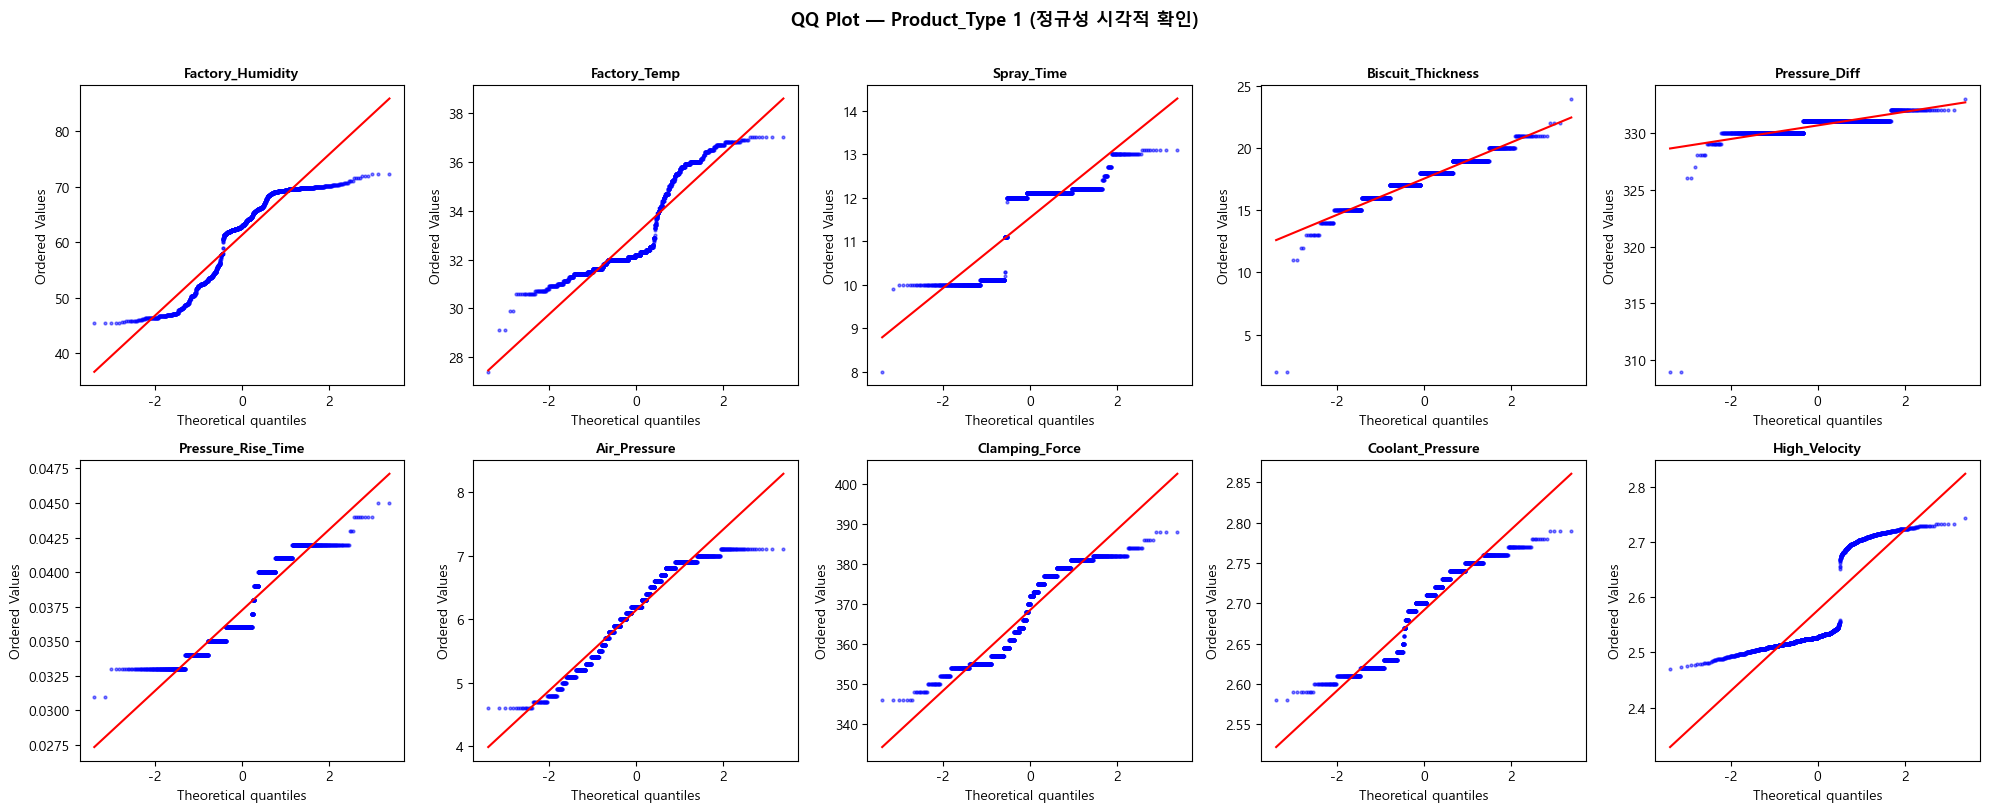

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(target_vars):
    stats.probplot(type2_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

plt.suptitle('QQ Plot — Product_Type 1 (정규성 시각적 확인)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Mann-Whitney U 검정

In [ ]:
from scipy.stats import mannwhitneyu

defect   = type2_df[type2_df['Defect_Status'] == 1]
normal   = type2_df[type2_df['Defect_Status'] == 0]

results = []
for col in target_vars:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
print(result_df.to_string(index=False))

                변수     U통계량  p-value 유의성
  Factory_Humidity 406486.5   0.0000   ✅
      Factory_Temp 255085.0   0.0000   ✅
        Spray_Time 442185.5   0.0000   ✅
Pressure_Rise_Time 294948.0   0.0000   ✅
    Clamping_Force 444534.0   0.0000   ✅
  Coolant_Pressure 440883.0   0.0000   ✅
     High_Velocity 251630.5   0.0000   ✅
 Biscuit_Thickness 387412.0   0.0321   ✅
     Pressure_Diff 376384.0   0.2131   ❌
      Air_Pressure 372569.5   0.4622   ❌


### 3. 효과크기 계산 (Rank-Biserial Correlation)

In [ ]:
from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

defect = type2_df[type2_df['Defect_Status'] == 1]
normal = type2_df[type2_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in target_vars:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
print(result_df.to_string(index=False))

                변수  p-value  효과크기(r) 해석
     High_Velocity   0.0000   0.3097  중
      Factory_Temp   0.0000   0.3003  중
    Clamping_Force   0.0000   0.2194  소
        Spray_Time   0.0000   0.2130  소
  Coolant_Pressure   0.0000   0.2094  소
Pressure_Rise_Time   0.0000   0.1909  소
  Factory_Humidity   0.0000   0.1150  소
 Biscuit_Thickness   0.0321   0.0627  소
     Pressure_Diff   0.2131   0.0325  소
      Air_Pressure   0.4622   0.0220  소


### 4. Kruskal-Wallis H 검정 (Defect_Type별 차이)

In [ ]:
from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']

results = []
for col in target_vars:
    groups = [type2_df[type2_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
print(result_df.to_string(index=False))

                변수  H통계량  p-value 유의성
  Factory_Humidity   NaN      NaN   ❌
      Factory_Temp   NaN      NaN   ❌
        Spray_Time   NaN      NaN   ❌
 Biscuit_Thickness   NaN      NaN   ❌
     Pressure_Diff   NaN      NaN   ❌
Pressure_Rise_Time   NaN      NaN   ❌
      Air_Pressure   NaN      NaN   ❌
    Clamping_Force   NaN      NaN   ❌
  Coolant_Pressure   NaN      NaN   ❌
     High_Velocity   NaN      NaN   ❌


C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120\155031766.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)
C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120\155031766.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)
C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120\155031766.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)
C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120\155031766.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)
C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120

In [ ]:
from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']
n_total = len(type2_df)

results = []
for col in target_vars:
    groups = [type2_df[type2_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    
    # epsilon-squared = H / (n - 1) / (n + 1) * n
    eps_sq = stat / (n_total - 1)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        'ε²': round(eps_sq, 4),
        '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
    })

result_df = pd.DataFrame(results).sort_values('ε²', ascending=False)
print(result_df.to_string(index=False))

                변수  H통계량  p-value  ε² 해석
  Factory_Humidity   NaN      NaN NaN  소
      Factory_Temp   NaN      NaN NaN  소
        Spray_Time   NaN      NaN NaN  소
 Biscuit_Thickness   NaN      NaN NaN  소
     Pressure_Diff   NaN      NaN NaN  소
Pressure_Rise_Time   NaN      NaN NaN  소
      Air_Pressure   NaN      NaN NaN  소
    Clamping_Force   NaN      NaN NaN  소
  Coolant_Pressure   NaN      NaN NaN  소
     High_Velocity   NaN      NaN NaN  소


C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120\1293523129.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)
C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120\1293523129.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)
C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120\1293523129.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)
C:\Users\asdxo\AppData\Local\Temp\ipykernel_7120\1293523129.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = kruskal(*groups)
C:\Users\asdxo\AppData\Local\Temp\ipykernel_